In [ ]:
# ADSL: demographics
adsl_small = adsl[["USUBJID", "AGE", "SEX", "EDUC"]].copy()
# extract PTID from USUBJID 
adsl_small["PTID"] = adsl_small["USUBJID"].str.extract(r"(\d{3}_S_\d{4})")
# APOE: genetics
# adjust this if APOERES uses a slightly different APOE column name
apoe_cols = [c for c in ["RID", "PTID", "APOE", "APOE4"] if c in apoe.columns]
apoe_small = apoe[apoe_cols].copy()
# ADAS: cognition
adas_small = adas[["RID", "PTID", "VISCODE", "TOTSCORE", "TOTAL13"]].copy()


In [ ]:
adas_small = adas[["RID", "PTID", "VISCODE", "TOTSCORE", "TOTAL13"]].copy()
dx_small = dxsum[["RID", "PTID", "VISCODE", "DIAGNOSIS"]].copy()
apoe_small = apoe[["RID", "PTID", "VISCODE", "GENOTYPE"]].copy()


In [ ]:
merged = adas_small.merge(dx_small, on=["RID", "PTID", "VISCODE"], how="inner")


In [ ]:
merged_apoe = merged.merge(apoe_small, on=["RID", "PTID", "VISCODE"], how="left")


In [ ]:
# baseline and m06 tables from merged_apoe
bl = merged_apoe[merged_apoe["VISCODE"] == "bl"].copy()
m06 = merged_apoe[merged_apoe["VISCODE"] == "m06"].copy()
progression = bl.merge(
    m06[["RID", "PTID", "TOTSCORE", "TOTAL13"]],
    on=["RID", "PTID"],
    how="inner",
    suffixes=("_bl", "_m06")
)
# keep only baseline MCI
progression = progression[progression["DIAGNOSIS"] == 2].copy()
# delta features
progression["delta_ADAS"] = progression["TOTSCORE_m06"] - progression["TOTSCORE_bl"]
progression["delta_ADAS13"] = progression["TOTAL13_m06"] - progression["TOTAL13_bl"]
# label: 1 if patient ever becomes dementia, else 0
labels = {}
for rid in progression["RID"].unique():
    patient_data = merged_apoe[merged_apoe["RID"] == rid]
    labels[rid] = 1 if (patient_data["DIAGNOSIS"] == 3).any() else 0
progression["label"] = progression["RID"].map(labels)



In [ ]:
apoe_patient = (
    apoe_small[["RID", "PTID", "GENOTYPE"]]
    .dropna(subset=["GENOTYPE"])
    .drop_duplicates(subset=["RID", "PTID"])
    .copy()
)

In [ ]:
progression = progression.merge(
    apoe_patient,
    on=["RID", "PTID"],
    how="left"
)

In [ ]:
# Create APOE4 carrier feature
progression["APOE4_carrier"] = (
    progression["GENOTYPE"]
    .astype(str)
    .str.contains("4", na=False)
    .astype(int)
)



In [ ]:
progression_ids = progression[["RID", "PTID"]].drop_duplicates().copy()
progression_ids["SUBJID_from_PTID"] = progression_ids["PTID"].str.extract(r"_(\d+)$").astype(int)



In [ ]:
adsl_ids = adsl[["SUBJID"]].drop_duplicates().copy()

check = progression_ids.merge(
    adsl_ids,
    left_on="SUBJID_from_PTID",
    right_on="SUBJID",
    how="inner"
)

In [ ]:
# Keep only needed ADSL columns
adsl_small = adsl[[
    "SUBJID", "AGE", "SEX", "EDUC", "MMSCORE", "MOCA", "CDRSB", "FAQTOTAL"
]].copy()

# Build mapping table from progression PTID -> numeric SUBJID
progression_ids = progression[["RID", "PTID"]].drop_duplicates().copy()
progression_ids["SUBJID"] = progression_ids["PTID"].str.extract(r"_(\d+)$").astype(int)

# Only add SUBJID if it is not already present
if "SUBJID" not in progression.columns:
    progression = progression.merge(
        progression_ids[["RID", "PTID", "SUBJID"]],
        on=["RID", "PTID"],
        how="left"
    )

# Remove duplicate rows in ADSL by SUBJID if any
adsl_small = adsl_small.drop_duplicates(subset=["SUBJID"])

# Merge ADSL features
progression = progression.merge(
    adsl_small,
    on="SUBJID",
    how="left"
)

In [ ]:
# Encode sex
progression["SEX"] = progression["SEX"].map({"Male": 1, "Female": 0})

# Fill missing numeric values with median
for col in ["AGE", "EDUC", "MMSCORE", "MOCA", "CDRSB", "FAQTOTAL"]:
    progression[col] = progression[col].fillna(progression[col].median())

In [ ]:
check_cols = [
    "AGE", "SEX", "EDUC", "MMSCORE", "MOCA", "CDRSB", "FAQTOTAL",
    "TOTSCORE_bl", "TOTAL13_bl", "delta_ADAS", "delta_ADAS13",
    "APOE4_carrier", "label"
]

## Model Training 

In [ ]:
model_cols = [
    "AGE",
    "EDUC",
    "MMSCORE",
    "CDRSB",
    "FAQTOTAL",
    "TOTSCORE_bl",
    "TOTAL13_bl",
    "APOE4_carrier",
    "label"
]

model_data = progression[model_cols].dropna()

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

X = model_data.drop("label", axis=1)
y = model_data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scale_pos_weight = len(y[y == 0]) / len(y[y == 1])

model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

XGBoost Results
Accuracy: 0.696969696969697
AUC: 0.7965811965811965

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.68      0.73        60
           1       0.60      0.72      0.65        39

    accuracy                           0.70        99
   macro avg       0.69      0.70      0.69        99
weighted avg       0.71      0.70      0.70        99


Confusion Matrix:
 [[41 19]
 [11 28]]


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# Initialize model
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')

# Train
log_model.fit(X_train, y_train)

# Predict
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# Evaluate
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("AUC:", roc_auc_score(y_test, y_prob_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.7272727272727273
AUC: 0.7978632478632479

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.75      0.77        60
           1       0.64      0.69      0.67        39

    accuracy                           0.73        99
   macro avg       0.72      0.72      0.72        99
weighted avg       0.73      0.73      0.73        99


Confusion Matrix:
 [[45 15]
 [12 27]]


In [36]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.7272727272727273
AUC: 0.7854700854700855

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.78      0.78        60
           1       0.66      0.64      0.65        39

    accuracy                           0.73        99
   macro avg       0.71      0.71      0.71        99
weighted avg       0.73      0.73      0.73        99


Confusion Matrix:
 [[47 13]
 [14 25]]


## ROC Curve Comparison

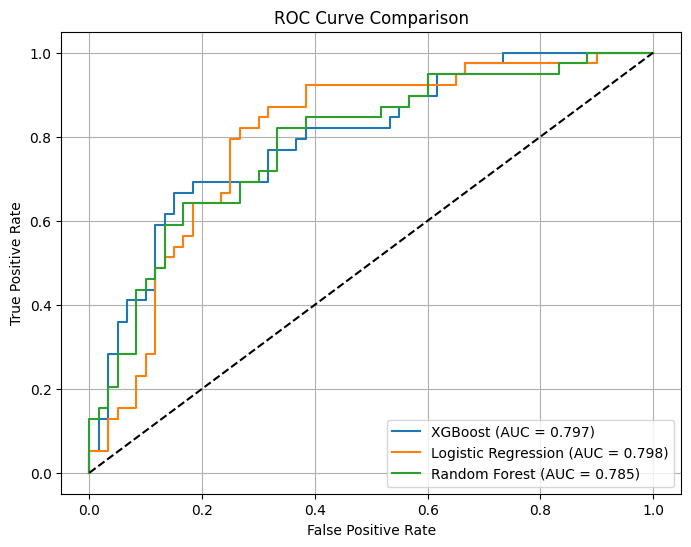

In [38]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# XGBoost
y_prob_xgb = model.predict_proba(X_test)[:, 1]

# Logistic Regression
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# Random Forest
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

#ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# AUC
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')

# Diagonal line (random model)
plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid()

plt.show()

## Correlation Analysis

                    AGE      EDUC   MMSCORE     CDRSB  FAQTOTAL  TOTSCORE_bl  \
AGE            1.000000 -0.062233 -0.193029  0.009633  0.069705     0.132788   
EDUC          -0.062233  1.000000  0.191400 -0.021670  0.032372    -0.179040   
MMSCORE       -0.193029  0.191400  1.000000 -0.162686 -0.113744    -0.386777   
CDRSB          0.009633 -0.021670 -0.162686  1.000000  0.563872     0.229284   
FAQTOTAL       0.069705  0.032372 -0.113744  0.563872  1.000000     0.258240   
TOTSCORE_bl    0.132788 -0.179040 -0.386777  0.229284  0.258240     1.000000   
TOTAL13_bl     0.162670 -0.198770 -0.432439  0.267389  0.297469     0.948869   
APOE4_carrier -0.129071 -0.022771 -0.098291  0.105354  0.119304     0.207006   

               TOTAL13_bl  APOE4_carrier  
AGE              0.162670      -0.129071  
EDUC            -0.198770      -0.022771  
MMSCORE         -0.432439      -0.098291  
CDRSB            0.267389       0.105354  
FAQTOTAL         0.297469       0.119304  
TOTSCORE_bl      0.94

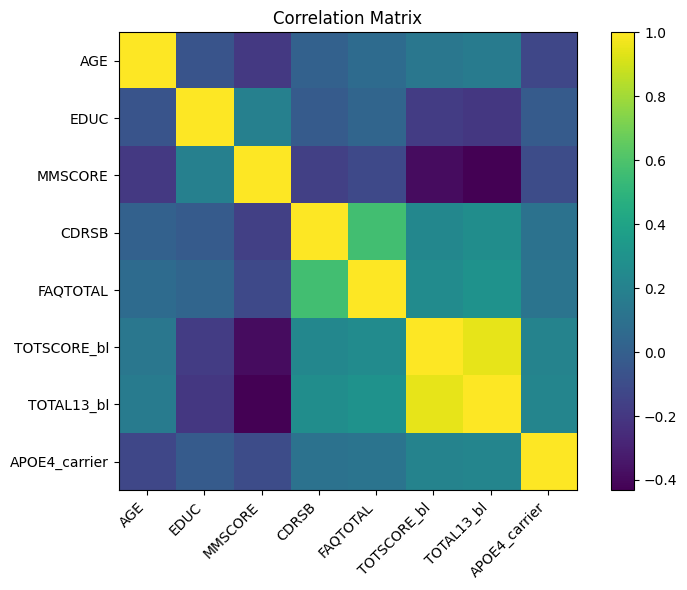

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

feature_cols = [
    "AGE",
    "EDUC",
    "MMSCORE",
    "CDRSB",
    "FAQTOTAL",
    "TOTSCORE_bl",
    "TOTAL13_bl",
    "APOE4_carrier"
]

corr = model_data[feature_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(feature_cols)), feature_cols, rotation=45, ha="right")
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## SHAP Explainability

c:\Users\AISWARYA\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


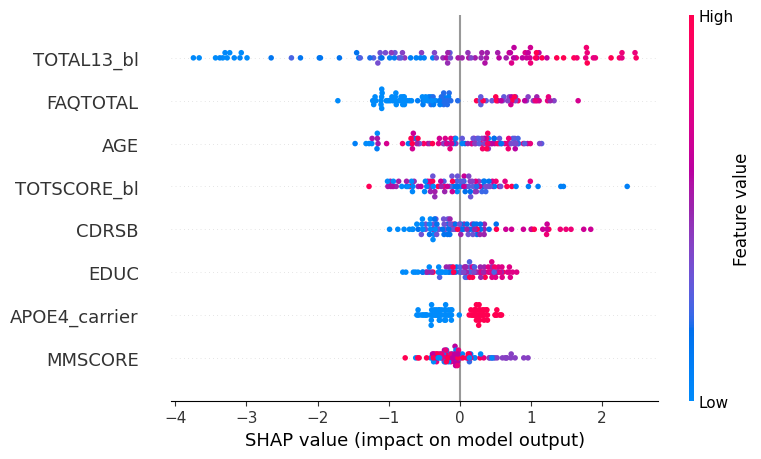

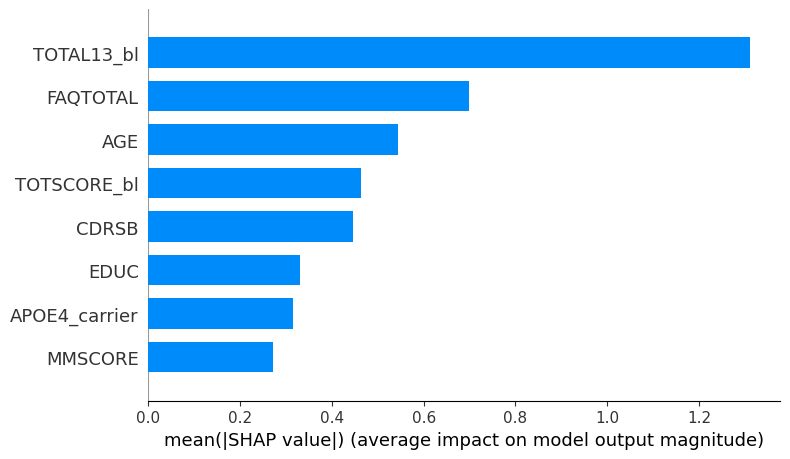

In [40]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary beeswarm
shap.summary_plot(shap_values, X_test)

# Bar summary
shap.summary_plot(shap_values, X_test, plot_type="bar")

## Statistical Testing

In [41]:
import scipy.stats as stats

group0 = progression[progression["label"] == 0]
group1 = progression[progression["label"] == 1]

features = [
    "AGE", "EDUC", "MMSCORE", "CDRSB", "FAQTOTAL",
    "TOTSCORE_bl", "TOTAL13_bl", "delta_ADAS", "delta_ADAS13"
    
]

for col in features:
    stat, p = stats.ttest_ind(group0[col], group1[col], nan_policy='omit')
    print(f"{col}: p-value = {p:.5f}")

AGE: p-value = 0.30243
EDUC: p-value = 0.66547
MMSCORE: p-value = 0.00001
CDRSB: p-value = 0.00000
FAQTOTAL: p-value = 0.00000
TOTSCORE_bl: p-value = 0.00000
TOTAL13_bl: p-value = 0.00000
delta_ADAS: p-value = 0.00583
delta_ADAS13: p-value = 0.00114


In [43]:
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(progression["APOE4_carrier"], progression["label"])
chi2, p, _, _ = chi2_contingency(table)

print(table)
print("p-value:", p)

label            0    1
APOE4_carrier          
0              154   84
1              109  148
p-value: 1.0829606543308678e-06


## Conclusion

In [ ]:
#Logistic Regression achieved the best performance with an AUC of ~0.80, closely followed by Random Forest and XGBoost.

#Key predictors of Alzheimer’s progression include:
# 1) Baseline cognitive scores (ADAS, CDRSB)
# 2) Functional scores (FAQ)
# 3) APOE4 genetic status

#Statistical testing confirmed significant differences between progressing and non-progressing patients.
